# EduPredict AI
## Student Performance Analytics & Success Risk Prediction System

**IBM SkillsBuild Data Analytics with AI Internship 2026**

### Project Objective
This project analyzes student-related data to identify factors associated
with academic performance and uses machine learning to predict student
performance and classify performance risk.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("EduPredict AI environment is ready!")

EduPredict AI environment is ready!


## 1. Importing and Loading the Dataset

In [5]:
df = pd.read_csv("data/student-mat.csv", sep=";")

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (395, 33)


## 2. Initial Data Exploration

In [6]:
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 395
Columns: 33


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [72]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [73]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## 3. Understanding Student Performance

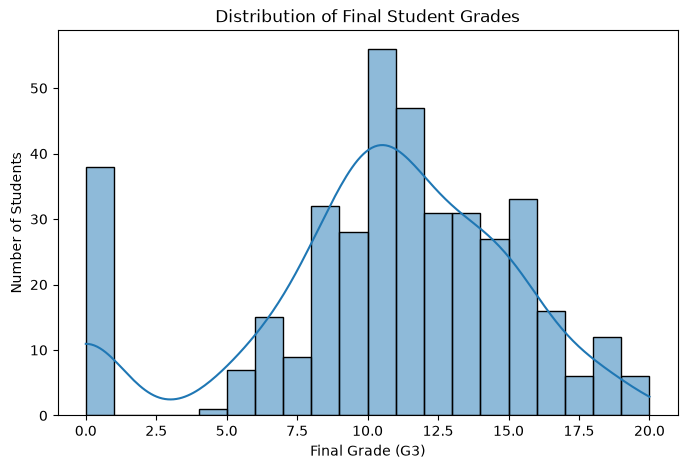

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Student Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

In [75]:
print("Average Final Grade:", round(df["G3"].mean(), 2))
print("Highest Final Grade:", df["G3"].max())
print("Lowest Final Grade:", df["G3"].min())


Average Final Grade: 10.42
Highest Final Grade: 20
Lowest Final Grade: 0


## 4. Data Cleaning
### 4.1 Checking Duplicate Records

In [76]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


### 4.2 Checking Missing Values

In [77]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])


Series([], dtype: int64)


In [78]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 0


### 4.3 Checking Data Types

In [79]:
df.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [80]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:10])


school:
<ArrowStringArray>
['GP', 'MS']
Length: 2, dtype: str

sex:
<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str

age:
[18 17 15 16 19 22 20 21]

address:
<ArrowStringArray>
['U', 'R']
Length: 2, dtype: str

famsize:
<ArrowStringArray>
['GT3', 'LE3']
Length: 2, dtype: str

Pstatus:
<ArrowStringArray>
['A', 'T']
Length: 2, dtype: str

Medu:
[4 1 3 2 0]

Fedu:
[4 1 2 3 0]

Mjob:
<ArrowStringArray>
['at_home', 'health', 'other', 'services', 'teacher']
Length: 5, dtype: str

Fjob:
<ArrowStringArray>
['teacher', 'other', 'services', 'health', 'at_home']
Length: 5, dtype: str

reason:
<ArrowStringArray>
['course', 'other', 'home', 'reputation']
Length: 4, dtype: str

guardian:
<ArrowStringArray>
['mother', 'father', 'other']
Length: 3, dtype: str

traveltime:
[2 1 3 4]

studytime:
[2 3 1 4]

failures:
[0 3 2 1]

schoolsup:
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

famsup:
<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

paid:
<ArrowStringArray>
['no', 'yes']
Leng

In [81]:
print("Average:", df["G3"].mean())
print("Median:", df["G3"].median())
print("Minimum:", df["G3"].min())
print("Maximum:", df["G3"].max())

Average: 10.415189873417722
Median: 11.0
Minimum: 0
Maximum: 20


In [82]:
df["G3"].value_counts().sort_index()

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64

### 4.4 Creating Student Performance Categories

To make the analysis easier to interpret, final grades are grouped into
three project-defined performance categories: Low, Medium and High.

In [83]:
def performance_category(score):
    if score >= 15:
        return "High"
    elif score >= 10:
        return "Medium"
    else:
        return "Low"

df["Performance_Category"] = df["G3"].apply(performance_category)

df[["G3", "Performance_Category"]].head(10)

,G3,Performance_Category
0,6,Low
1,6,Low
2,10,Medium
3,15,High
4,10,Medium
5,15,High
6,11,Medium
7,6,Low
8,19,High
9,15,High


In [84]:
category_counts = df["Performance_Category"].value_counts()

print(category_counts)

Performance_Category
Medium    192
Low       130
High       73
Name: count, dtype: int64


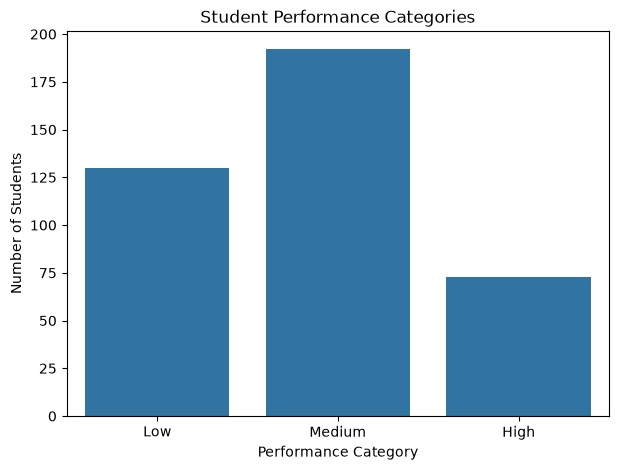

In [85]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Performance_Category",
    order=["Low", "Medium", "High"]
)

plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

In [86]:
analysis_df = df[
    [
        "age",
        "studytime",
        "failures",
        "absences",
        "G1",
        "G2",
        "G3",
        "Performance_Category"
    ]
]

analysis_df.head()

,age,studytime,failures,absences,G1,G2,G3,Performance_Category
0,18,2,0,6,5,6,6,Low
1,17,2,0,4,5,5,6,Low
2,15,2,3,10,7,8,10,Medium
3,15,3,0,2,15,14,15,High
4,16,2,0,4,6,10,10,Medium


In [87]:
correlation = df[
    ["age", "studytime", "failures", "absences", "G1", "G2", "G3"]
].corr()

correlation["G3"].sort_values(ascending=False)

G3           1.000000
G2           0.904868
G1           0.801468
studytime    0.097820
absences     0.034247
age         -0.161579
failures    -0.360415
Name: G3, dtype: float64

## 5. Exploratory Data Analysis

### 5.1 Study Time and Student Performance

In [88]:
study_performance = df.groupby("studytime")["G3"].mean()

print(study_performance)

studytime
1    10.047619
2    10.171717
3    11.400000
4    11.259259
Name: G3, dtype: float64


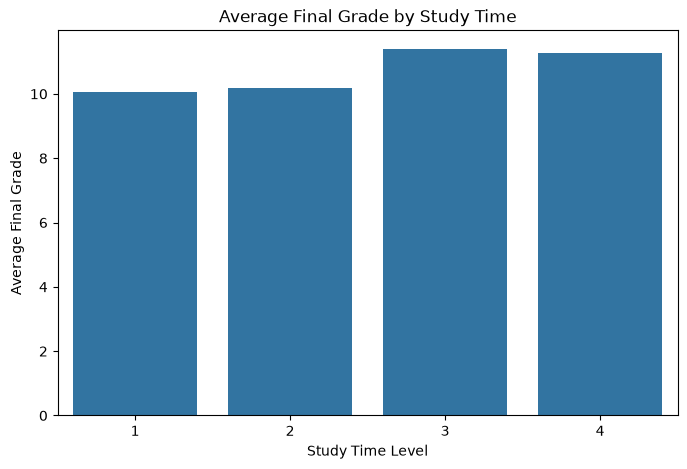

In [89]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=study_performance.index,
    y=study_performance.values
)

plt.title("Average Final Grade by Study Time")
plt.xlabel("Study Time Level")
plt.ylabel("Average Final Grade")

plt.show()

### 5.2 Previous Grades and Final Performance

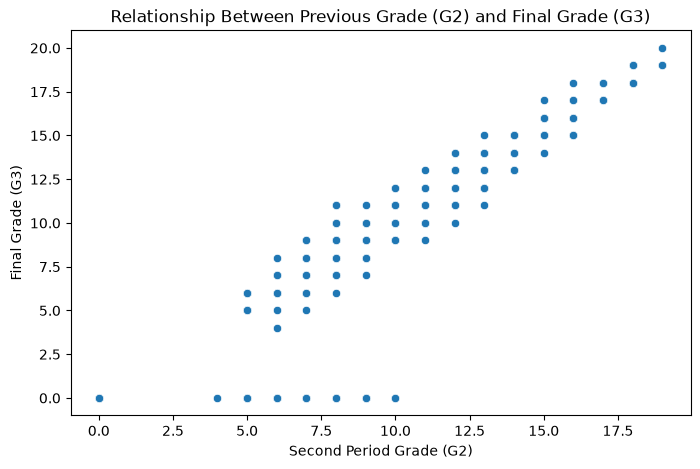

In [90]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="G2",
    y="G3"
)

plt.title("Relationship Between Previous Grade (G2) and Final Grade (G3)")
plt.xlabel("Second Period Grade (G2)")
plt.ylabel("Final Grade (G3)")

plt.show()

In [91]:
print("Correlation between G2 and G3:",
      round(df["G2"].corr(df["G3"]), 3))

Correlation between G2 and G3: 0.905


### 5.3 Absences and Student Performance

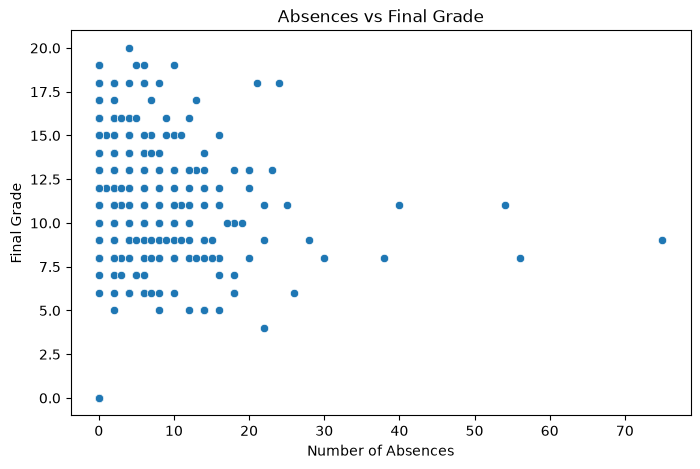

In [92]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="absences",
    y="G3"
)

plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")

plt.show()

In [93]:
print("Correlation between Absences and G3:",
      round(df["absences"].corr(df["G3"]), 3))

Correlation between Absences and G3: 0.034


### 5.4 Previous Failures and Student Performance

In [94]:
failure_performance = df.groupby("failures")["G3"].mean()

print(failure_performance)

failures
0    11.253205
1     8.120000
2     6.235294
3     5.687500
Name: G3, dtype: float64


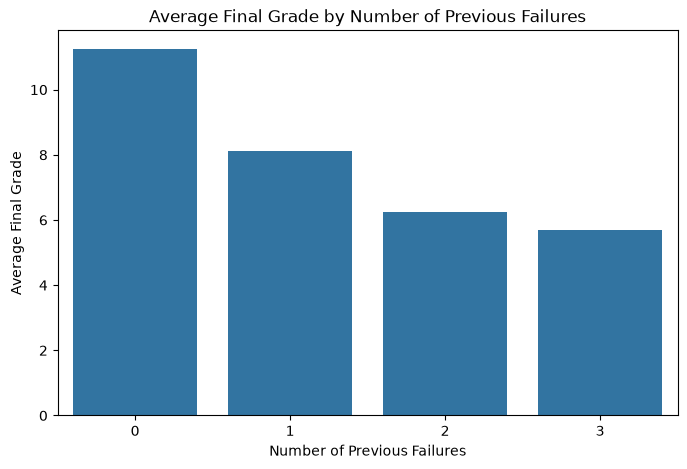

In [95]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=failure_performance.index,
    y=failure_performance.values
)

plt.title("Average Final Grade by Number of Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Average Final Grade")

plt.show()

### 5.5 Gender and Student Performance

In [96]:
gender_performance = df.groupby("sex")["G3"].mean()

print(gender_performance)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


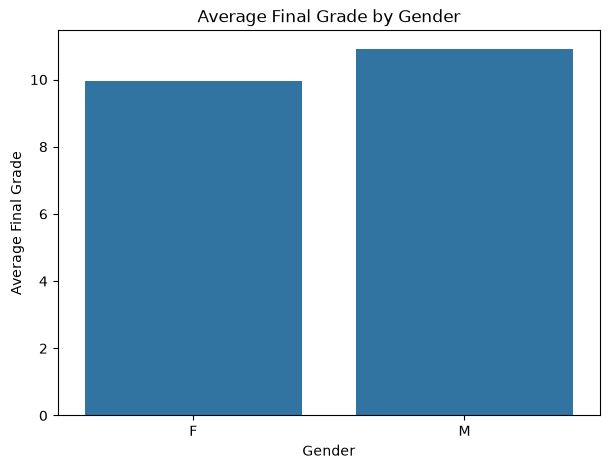

In [97]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=gender_performance.index,
    y=gender_performance.values
)

plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade")

plt.show()

Performance_Category

In [98]:
category_percentage = (
    df["Performance_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(category_percentage)

Performance_Category
Medium    48.61
Low       32.91
High      18.48
Name: proportion, dtype: float64


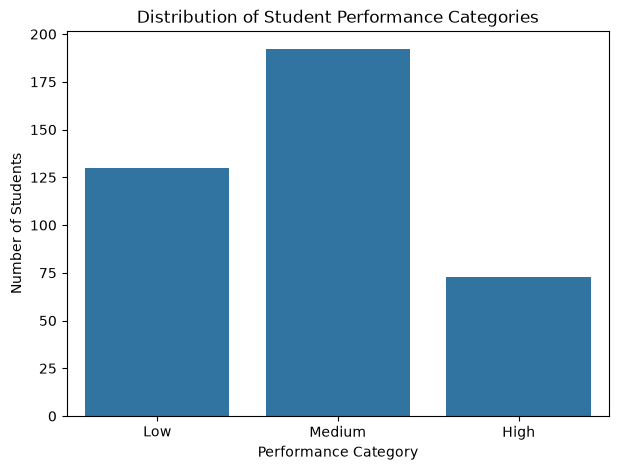

In [99]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Performance_Category",
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

## 5.7 Key EDA Observations

The exploratory analysis examines relationships between student performance
and factors such as study time, previous grades, absences, and previous
failures.

The observations from the charts and statistical analysis will be used to
identify relevant features for the machine learning model.

In [100]:
numeric_columns = [
    "age",
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
    "G3"
]

correlation_with_g3 = (
    df[numeric_columns]
    .corr()["G3"]
    .sort_values(ascending=False)
)

print(correlation_with_g3)

G3           1.000000
G2           0.904868
G1           0.801468
studytime    0.097820
absences     0.034247
age         -0.161579
failures    -0.360415
Name: G3, dtype: float64


# 6. Machine Learning

## 6.1 Feature Selection

The selected features represent student characteristics and previous
academic performance. The target variable is the final grade (G3).

In [101]:
features = [
    "age",
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2"
]

X = df[features]
y = df["G3"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (395, 6)
Target shape: (395,)


## 6.2 Train-Test Split


In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 316
Testing samples: 79


## 6.3 Model 1 — Linear Regression

In [103]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [104]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²  :", round(linear_r2, 3))

Linear Regression Results
-------------------------
MAE : 1.334
RMSE: 2.112
R²  : 0.782


## 6.4 Model 2 — Random Forest Regression

In [105]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [106]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

Random Forest Results
---------------------
MAE : 1.038
RMSE: 1.732
R²  : 0.854


In [107]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.334018,2.112361,0.782392
1,Random Forest,1.037802,1.731820,0.853734


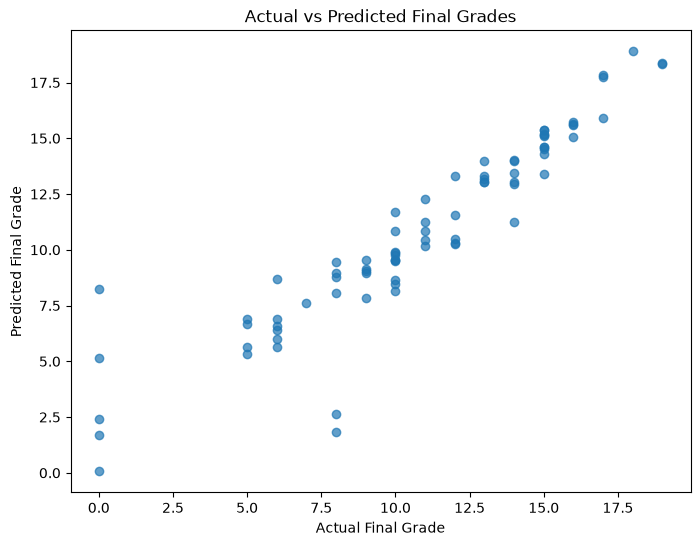

In [108]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Final Grades")

plt.show()

In [109]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,G2,0.800512
3,absences,0.117272
0,age,0.037721
4,G1,0.025397
1,studytime,0.010867
2,failures,0.008231


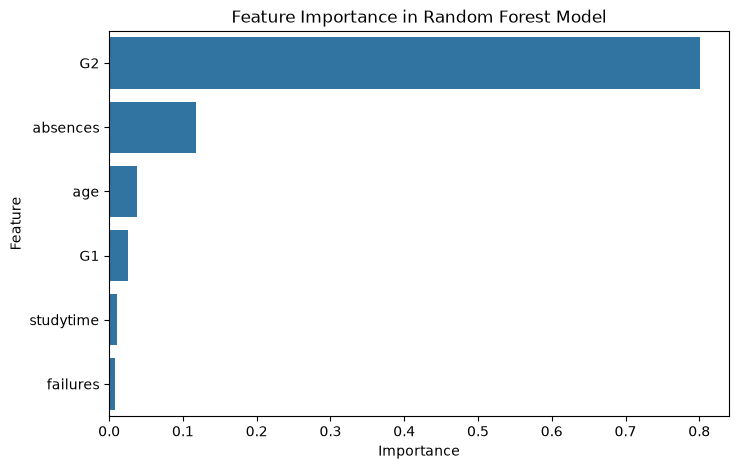

In [110]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 6.5 Student Performance Prediction

In [111]:
def predict_student_performance(
    age,
    studytime,
    failures,
    absences,
    G1,
    G2
):
    student_data = pd.DataFrame({
        "age": [age],
        "studytime": [studytime],
        "failures": [failures],
        "absences": [absences],
        "G1": [G1],
        "G2": [G2]
    })

    prediction = random_forest.predict(student_data)[0]

    return round(prediction, 2)

In [112]:
predicted_grade = predict_student_performance(
    age=17,
    studytime=2,
    failures=0,
    absences=5,
    G1=12,
    G2=13
)

print("Predicted Final Grade:", predicted_grade)

Predicted Final Grade: 13.23


predicted_grade = predict_student_performance(
    age=17,
    studytime=2,
    failures=0,
    absences=5,
    G1=12,
    G2=13
)

print("Predicted Final Grade:", predicted_grade)

In [113]:
def get_performance_category(predicted_grade):
    if predicted_grade >= 15:
        return "High Performance"
    elif predicted_grade >= 10:
        return "Medium Performance"
    else:
        return "Low Performance"

In [114]:
print(get_performance_category(16))
print(get_performance_category(12))
print(get_performance_category(8))

High Performance
Medium Performance
Low Performance


In [115]:
def analyze_student(
    age,
    studytime,
    failures,
    absences,
    G1,
    G2
):
    predicted_grade = predict_student_performance(
        age,
        studytime,
        failures,
        absences,
        G1,
        G2
    )

    category = get_performance_category(predicted_grade)

    return predicted_grade, category

In [116]:
grade, category = analyze_student(
    age=17,
    studytime=2,
    failures=0,
    absences=5,
    G1=12,
    G2=13
)

print("Predicted Final Grade:", grade)
print("Performance Category:", category)

Predicted Final Grade: 13.23
Performance Category: Medium Performance


In [117]:
df["Predicted_G3"] = random_forest.predict(df[features])

In [118]:
df[["G3", "Predicted_G3"]].head(10)

,G3,Predicted_G3
0,6,6.910000
1,6,5.580000
2,10,9.480000
3,15,14.300000
4,10,9.781667
5,15,15.380000
6,11,11.280000
7,6,5.640000
8,19,18.443833
9,15,14.610000


In [119]:
df["Predicted_Category"] = df["Predicted_G3"].apply(
    get_performance_category
)

In [120]:
df[
    [
        "G3",
        "Predicted_G3",
        "Predicted_Category"
    ]
].head(10)

,G3,Predicted_G3,Predicted_Category
0,6,6.910000,Low Performance
1,6,5.580000,Low Performance
2,10,9.480000,Low Performance
3,15,14.300000,Medium Performance
4,10,9.781667,Low Performance
5,15,15.380000,High Performance
6,11,11.280000,Medium Performance
7,6,5.640000,Low Performance
8,19,18.443833,High Performance
9,15,14.610000,Medium Performance


In [121]:
category_comparison = pd.crosstab(
    df["Performance_Category"],
    df["Predicted_Category"]
)

category_comparison

Predicted_Category,High Performance,Low Performance,Medium Performance
Performance_Category,,,
High,62,0,11
Low,0,130,0
Medium,0,38,154


In [122]:
df["Prediction_Error"] = (
    df["G3"] - df["Predicted_G3"]
).abs()

In [123]:
print(
    "Average Prediction Error:",
    round(df["Prediction_Error"].mean(), 2)
)

Average Prediction Error: 0.52


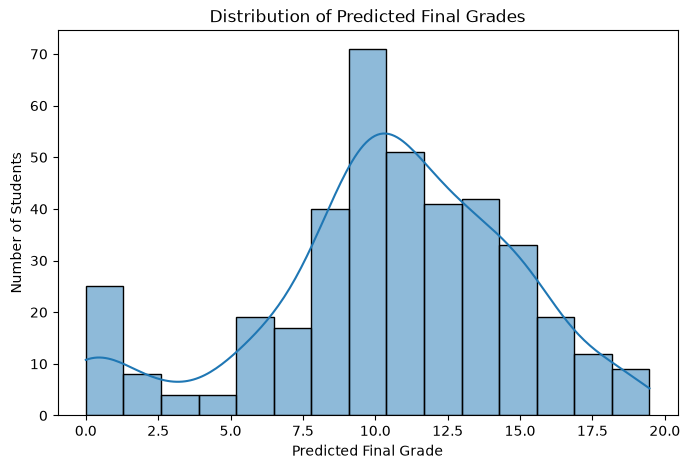

In [124]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Predicted_G3"],
    bins=15,
    kde=True
)

plt.title("Distribution of Predicted Final Grades")
plt.xlabel("Predicted Final Grade")
plt.ylabel("Number of Students")

plt.show()

In [125]:
student_analysis = df[
    [
        "age",
        "studytime",
        "failures",
        "absences",
        "G1",
        "G2",
        "G3",
        "Predicted_G3",
        "Performance_Category",
        "Predicted_Category"
    ]
].copy()

student_analysis.head(10)

,age,studytime,failures,absences,G1,G2,G3,Predicted_G3,Performance_Category,Predicted_Category
0,18,2,0,6,5,6,6,6.910000,Low,Low Performance
1,17,2,0,4,5,5,6,5.580000,Low,Low Performance
2,15,2,3,10,7,8,10,9.480000,Medium,Low Performance
3,15,3,0,2,15,14,15,14.300000,High,Medium Performance
4,16,2,0,4,6,10,10,9.781667,Medium,Low Performance
5,16,2,0,10,15,15,15,15.380000,High,High Performance
6,16,2,0,0,12,12,11,11.280000,Medium,Medium Performance
7,17,2,0,6,6,5,6,5.640000,Low,Low Performance
8,15,2,0,0,16,18,19,18.443833,High,High Performance
9,15,2,0,0,14,15,15,14.610000,High,Medium Performance


In [126]:
student_analysis.to_csv(
    "outputs/student_performance_predictions.csv",
    index=False
)

model_results.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "outputs/feature_importance.csv",
    index=False
)

print("Output files created successfully!")

Output files created successfully!


# 8. Project Summary

## Key Components

### Data Analytics
The project explores student characteristics, study patterns, previous
academic performance and their relationships with final grades.

### Machine Learning
Two regression models, Linear Regression and Random Forest Regression,
are trained and evaluated.

### Prediction
The selected model predicts the final student grade.

### Performance Analysis
Predicted grades are converted into project-defined performance categories
to make the results easier to interpret.

### Output
The project generates prediction results, model comparison results and
feature importance information as CSV files.

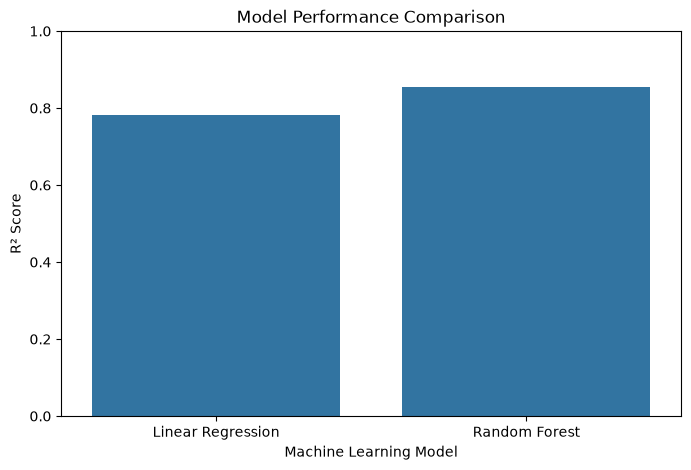

In [127]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.show()

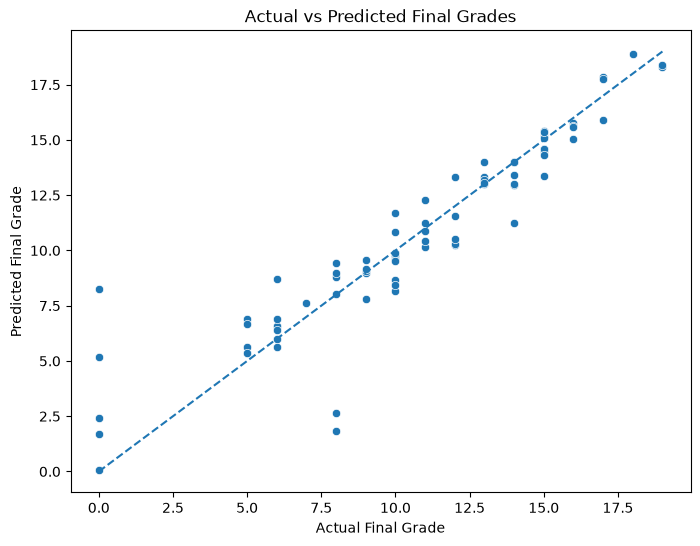

In [128]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=rf_predictions
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Final Grades")
plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")

plt.show()

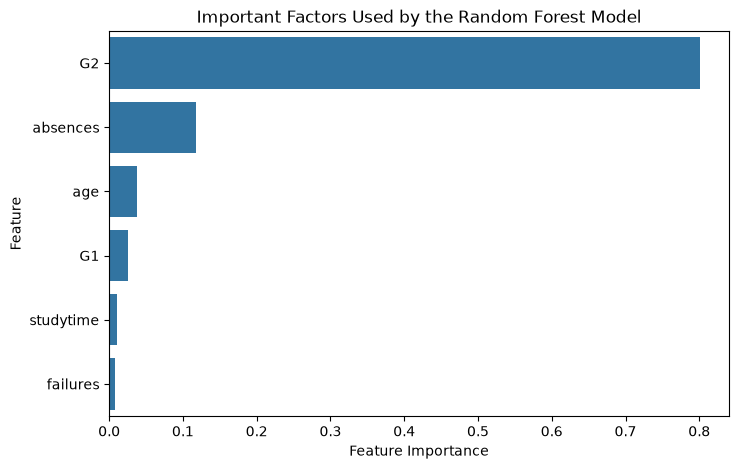

In [129]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Important Factors Used by the Random Forest Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

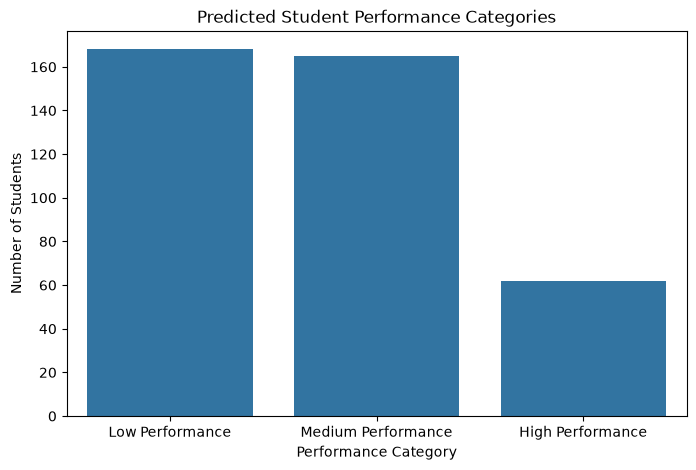

In [130]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Predicted_Category",
    order=[
        "Low Performance",
        "Medium Performance",
        "High Performance"
    ]
)

plt.title("Predicted Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

In [131]:
print("========== EduPredict AI Summary ==========")

print("Total Students:", len(df))

print(
    "Average Actual Grade:",
    round(df["G3"].mean(), 2)
)

print(
    "Average Predicted Grade:",
    round(df["Predicted_G3"].mean(), 2)
)

print(
    "Average Prediction Error:",
    round(df["Prediction_Error"].mean(), 2)
)

print(
    "Best Model:",
    model_results.loc[
        model_results["R2 Score"].idxmax(),
        "Model"
    ]
)

print(
    "Best R² Score:",
    round(model_results["R2 Score"].max(), 3)
)

print("\nPredicted Performance Categories:")
print(df["Predicted_Category"].value_counts())

========== EduPredict AI Summary ==========
Total Students: 395
Average Actual Grade: 10.42
Average Predicted Grade: 10.44
Average Prediction Error: 0.52
Best Model: Random Forest
Best R² Score: 0.854

Predicted Performance Categories:
Predicted_Category
Low Performance       168
Medium Performance    165
High Performance       62
Name: count, dtype: int64


In [132]:
print("========== Key Insights ==========")

print(
    "1. The dataset contains",
    len(df),
    "student records."
)

print(
    "2. The average final grade is",
    round(df["G3"].mean(), 2)
)

print(
    "3. The feature most important to the Random Forest model is",
    feature_importance.iloc[0]["Feature"]
)

print(
    "4. The Random Forest model achieved an R² score of",
    round(rf_r2, 3)
)

print(
    "5. The average prediction error is",
    round(df["Prediction_Error"].mean(), 2),
    "grade points."
)

print(
    "6. The most common predicted performance category is",
    df["Predicted_Category"].value_counts().idxmax()
)

========== Key Insights ==========
1. The dataset contains 395 student records.
2. The average final grade is 10.42
3. The feature most important to the Random Forest model is G2
4. The Random Forest model achieved an R² score of 0.854
5. The average prediction error is 0.52 grade points.
6. The most common predicted performance category is Low Performance
